In [1]:
import os
os.environ["TQDM_DISABLE"] = "1"

import time, cProfile, pstats, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

from tabpfn import TabPFNClassifier
from xgboost import XGBClassifier

import sys  
sys.path.insert(1, '/nvme/h/lchristodoulou/pace/cf-proposal/')
from get_real_datasets import load_many
from preprocessing import make_preprocessor, build_feature_info_from_pre


In [ ]:
def fit_models(X_tr_sc, y_tr, seed=0, include_tabpfn=True):
    models = {}

    lr = LogisticRegression(max_iter=5000, solver="lbfgs", random_state=seed)
    lr.fit(X_tr_sc, y_tr)
    models["LR"] = lr

    rf = RandomForestClassifier(
        n_estimators=400, random_state=seed, n_jobs=-1, min_samples_leaf=2
    )
    rf.fit(X_tr_sc, y_tr)
    models["RF"] = rf

    xgb = XGBClassifier(
        n_estimators=800, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", random_state=seed, n_jobs=-1,
    )
    xgb.fit(X_tr_sc, y_tr)
    models["XGB"] = xgb

    if include_tabpfn:
        tp = TabPFNClassifier(device="auto")
        tp.fit(X_tr_sc, y_tr)
        models["TabPFN"] = tp

    return models


In [3]:
# ── Real-dataset oracle cost: validates excluding NICE+TabPFN and DiCE+TabPFN ─
#
# NICE verifies each CF candidate by calling predict_proba once per candidate.
# DiCE calls predict_proba repeatedly during optimisation.
# Both assume the oracle is cheap (O(1) in n_train).
#
# TabPFN is an in-context learner: every predict_proba re-processes the full
# training context, so cost = O(n_train). This cell measures that directly on
# the two largest real datasets (california_housing_binarized, adult).

DATASETS   = ["credit-g", "breast_cancer", "diabetes"]
N_TEST     = 1      # single-row query, as NICE does for CF verification
N_REPEATS  = 3
SEED       = 0

real_datasets = load_many(DATASETS)

rows = []
for ds in real_datasets:
    print(f"\n=== {ds.name} ===")
    num_cols, cat_cols = ds.num_cols, ds.cat_cols
    pre = make_preprocessor(num_cols, cat_cols)

    X_df = ds.X_df
    y    = ds.y
    n    = len(y)
    split = int(0.8 * n)
    rng  = np.random.default_rng(SEED)
    idx  = rng.permutation(n)
    X_tr_sc = pre.fit_transform(X_df.iloc[idx[:split]])
    X_te_sc = pre.transform(X_df.iloc[idx[split:split + N_TEST]])
    y_tr    = y[idx[:split]]

    if hasattr(X_tr_sc, "toarray"):
        X_tr_sc = X_tr_sc.toarray()
    if hasattr(X_te_sc, "toarray"):
        X_te_sc = X_te_sc.toarray()

    print(f"  n_train={X_tr_sc.shape[0]:,}  n_features={X_tr_sc.shape[1]}")
    models_here = fit_models(X_tr_sc, y_tr, seed=SEED, include_tabpfn=True)

    for model_name, model in models_here.items():
        if model_name == "RF":
            continue
        times = []
        for _ in range(N_REPEATS):
            t0 = time.perf_counter()
            model.predict_proba(X_te_sc)
            times.append(time.perf_counter() - t0)
        t_med = float(np.median(times))
        print(f"  {model_name:<8s}  {t_med:.4f}s per query")
        rows.append({"dataset": ds.name, "model": model_name,
                     "n_train": X_tr_sc.shape[0], "time_s": t_med})

import pandas as pd
df_prof = pd.DataFrame(rows)
print("\n", df_prof.pivot(index="dataset", columns="model", values="time_s").to_string())


/nvme/h/lchristodoulou/.conda/envs/tabpfn/lib/python3.13/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)



=== credit-g ===
  n_train=800  n_features=61
  LR        0.0001s per query
  XGB       0.0004s per query
  TabPFN    0.5694s per query

=== breast_cancer ===
  n_train=455  n_features=30
  LR        0.0001s per query
  XGB       0.0004s per query
  TabPFN    0.3650s per query

=== diabetes_binarized ===
  n_train=353  n_features=10
  LR        0.0001s per query
  XGB       0.0004s per query
  TabPFN    0.3625s per query

 model                     LR    TabPFN       XGB
dataset                                         
breast_cancer       0.000097  0.365017  0.000388
credit-g            0.000114  0.569414  0.000443
diabetes_binarized  0.000090  0.362517  0.000418


TabPFN device: auto
n_train =    100 ... 

<>:69: SyntaxWarning: invalid escape sequence '\_'
<>:69: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_746663/3153907085.py:69: SyntaxWarning: invalid escape sequence '\_'
  ax.set_ylabel("predict\_proba time (s, log scale)", fontsize=11)


0.362s 0.000s 0.000s
n_train =    200 ... 0.356s 0.000s 0.000s
n_train =    500 ... 0.363s 0.000s 0.000s
n_train =   1000 ... 0.360s 0.000s 0.000s
n_train =   2000 ... 0.443s 0.000s 0.000s
n_train =   5000 ... 1.105s 0.000s 0.000s
n_train =  10000 ... 3.024s 0.000s 0.000s
n_train =  20000 ... 10.115s 0.000s 0.000s


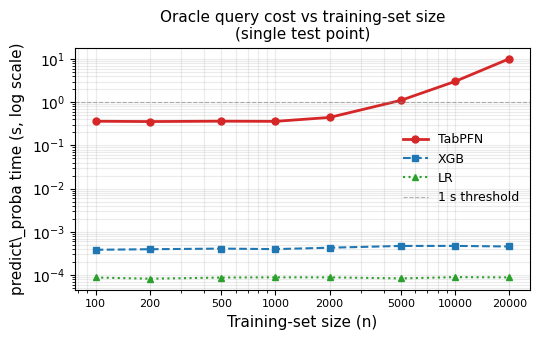

Saved tabpfn_scaling.pdf / .png


In [4]:
# ── TabPFN inference scaling with training-set size ──────────────────────────
# Shows why NICE + TabPFN hangs: every predict_proba call re-processes the
# full training context through the transformer, so cost grows with n_train.
# XGB and LR are included for reference (their predict time is O(1) in n_train).

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

N_TRAIN_VALUES = [100, 200, 500, 1000, 2000, 5000, 10000, 20000]
N_TEST         = 1          # single-row query (NICE verifies one CF at a time)
N_FEATURES     = 8          # matches california_housing_binarized
N_REPEATS      = 3          # repeat each timing to reduce noise
SEED           = 0

rng = np.random.default_rng(SEED)

# confirm device TabPFN will use
_probe = TabPFNClassifier(device="auto")
print(f"TabPFN device: {_probe.device}")
del _probe

results = {name: [] for name in ["TabPFN", "XGB", "LR"]}

for n_train in N_TRAIN_VALUES:
    print(f"n_train = {n_train:>6d} ...", end=" ", flush=True)
    X, y = make_classification(
        n_samples=n_train + N_TEST,
        n_features=N_FEATURES,
        n_informative=5,
        random_state=SEED,
    )
    X_tr, y_tr = X[:n_train], y[:n_train]
    X_te       = X[n_train:]

    models_here = fit_models(X_tr, y_tr, seed=SEED, include_tabpfn=True)

    for model_name, model in models_here.items():
        if model_name not in results:
            continue
        times = []
        for _ in range(N_REPEATS):
            t0 = time.perf_counter()
            model.predict_proba(X_te)
            times.append(time.perf_counter() - t0)
        results[model_name].append(float(np.median(times)))

    print(" ".join(f"{results[m][-1]:.3f}s" for m in ["TabPFN", "XGB", "LR"]))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 3.5))

styles = {
    "TabPFN": dict(color="#d62728", marker="o", linewidth=2, markersize=5, label="TabPFN"),
    "XGB":    dict(color="#1f77b4", marker="s", linewidth=1.5, markersize=4, linestyle="--", label="XGB"),
    "LR":     dict(color="#2ca02c", marker="^", linewidth=1.5, markersize=4, linestyle=":",  label="LR"),
}

for name, style in styles.items():
    if name in results:
        ax.plot(N_TRAIN_VALUES, results[name], **style)

#ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.6, label="1 s threshold")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Training-set size (n)", fontsize=11)
ax.set_ylabel("predict\_proba time (s, log scale)", fontsize=11)
ax.set_title("Oracle query cost vs training-set size\n(single test point)", fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", alpha=0.25)
ax.set_xticks(N_TRAIN_VALUES)
ax.set_xticklabels(N_TRAIN_VALUES, fontsize=8)

plt.tight_layout()
plt.savefig("tabpfn_scaling.pdf", bbox_inches="tight")
plt.savefig("tabpfn_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved tabpfn_scaling.pdf / .png")
